In [24]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import ParameterGrid


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Original Dataset ===
       Class  Count
0  butterfly   2112
1        cat   1668
2    chicken   3098
3        cow   1866
4        dog   4863
5   elephant   1446
6      horse   2623
7      sheep   1820
8     spider   4830
9   squirrel   1871

Total samples: 26197


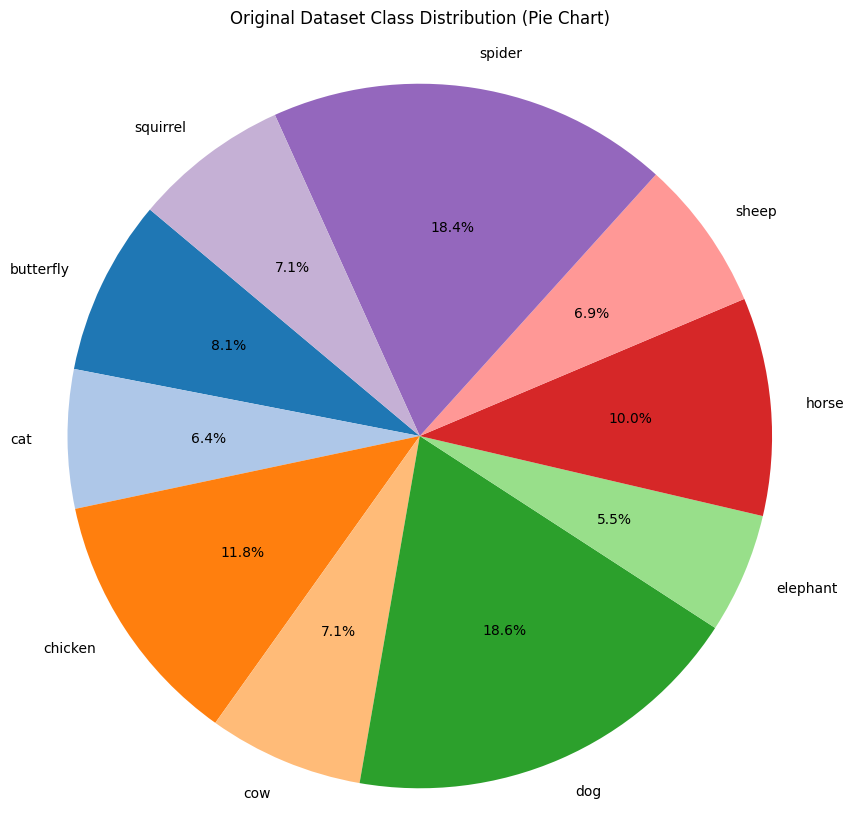

/tmp/ipython-input-1152198379.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=original_data, palette='viridis')


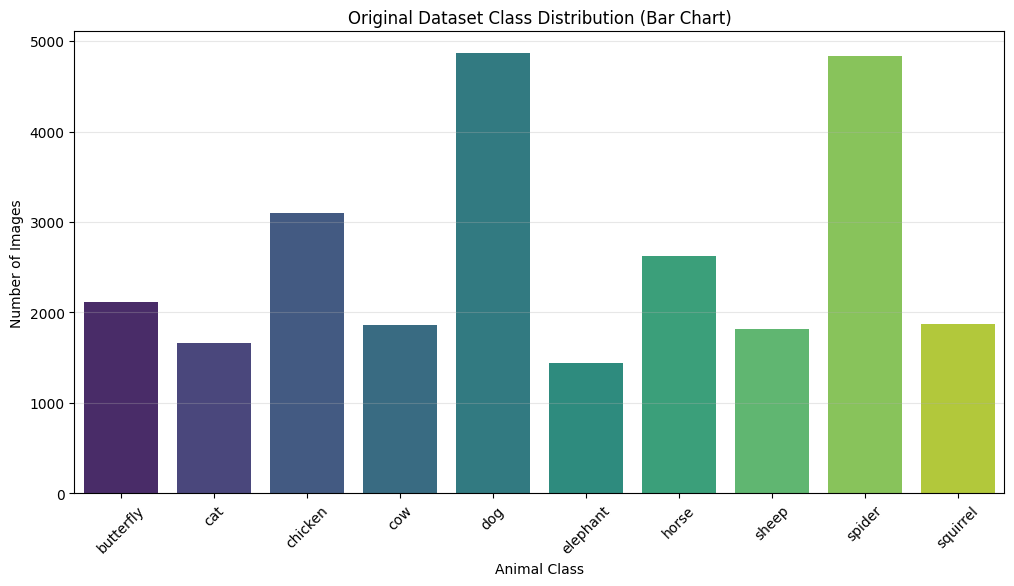


Sample Images from Each Class:


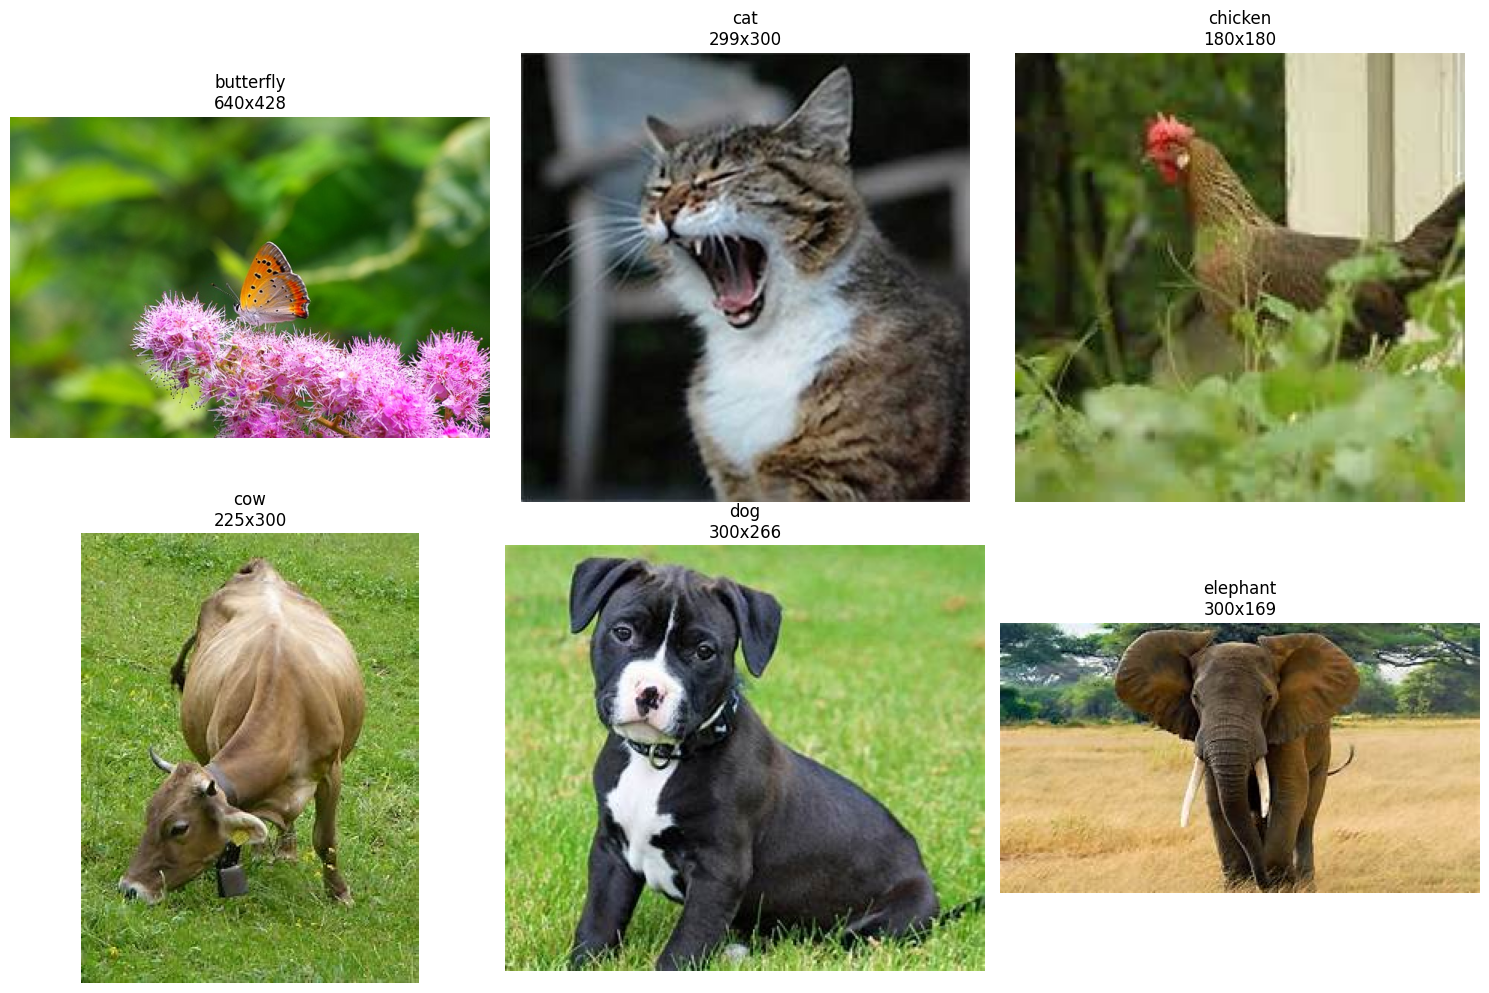


BLOCK 1.1 execution time: 6.04 seconds


In [25]:
# BLOCK 1.1: Original Dataset Visualization

# Set random seed for reproducibility
torch.manual_seed(42) # Ensures consistent torch operations across runs
np.random.seed(42)    # Ensures consistent numpy operations across runs

start_time = time.time()

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuration
DATA_PATH = '/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/animal_10/raw-img'
SUBSET_SIZE_PER_CLASS = 1440  # Can be changed later
TUNING_SUBSET_SIZE = 100    # Smaller subset for hyperparameter tuning
NUM_CLASSES = 10
BATCH_SIZE = 64
IMG_SIZE = 224

# Check if path exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Please verify the path.")

# Get class names and counts
class_names = sorted(os.listdir(DATA_PATH))
class_counts = []

for class_name in class_names:
    class_dir = os.path.join(DATA_PATH, class_name)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts.append(count)

# Create DataFrame for original dataset
original_data = pd.DataFrame({
    'Class': class_names,
    'Count': class_counts
})

print("=== Original Dataset ===")
print(original_data)
print(f"\nTotal samples: {original_data['Count'].sum()}")

# Visualization 1: Pie Chart
plt.figure(figsize=(10, 10))
plt.pie(original_data['Count'], labels=original_data['Class'],
        autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title('Original Dataset Class Distribution (Pie Chart)', pad=20)
plt.axis('equal')
plt.show()

# Visualization 2: Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=original_data, palette='viridis')
plt.title('Original Dataset Class Distribution (Bar Chart)')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')
plt.xlabel('Animal Class')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Visualization 3: Sample Images
print("\nSample Images from Each Class:")
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names[:6]):  # Show first 6 classes
    class_dir = os.path.join(DATA_PATH, class_name)
    img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if img_files:
        img_path = os.path.join(class_dir, np.random.choice(img_files))
        img = Image.open(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.size[0]}x{img.size[1]}")
        plt.axis('off')

plt.tight_layout()
plt.show()

end_time = time.time()
print(f"\nBLOCK 1.1 execution time: {end_time - start_time:.2f} seconds")


CREATING BALANCED SUBSET

=== Created Subset ===
       Class  Count
0  butterfly   1440
1        cat   1440
2    chicken   1440
3        cow   1440
4        dog   1440
5   elephant   1440
6      horse   1440
7      sheep   1440
8     spider   1440
9   squirrel   1440

Total subset samples: 14400


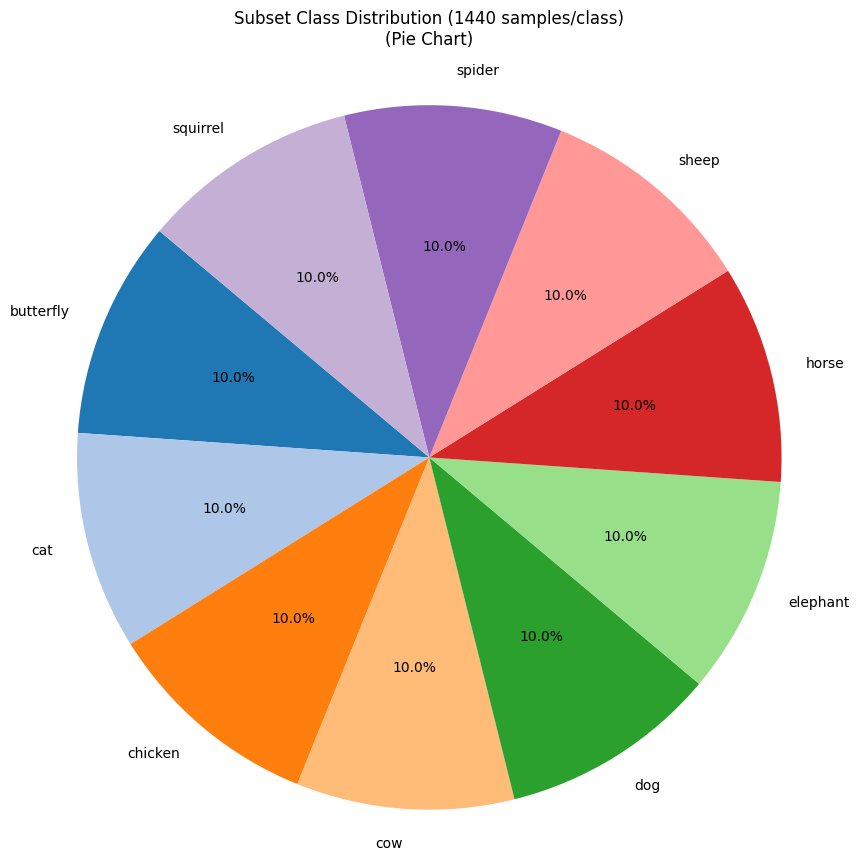

/tmp/ipython-input-464711678.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=subset_data, palette='viridis')


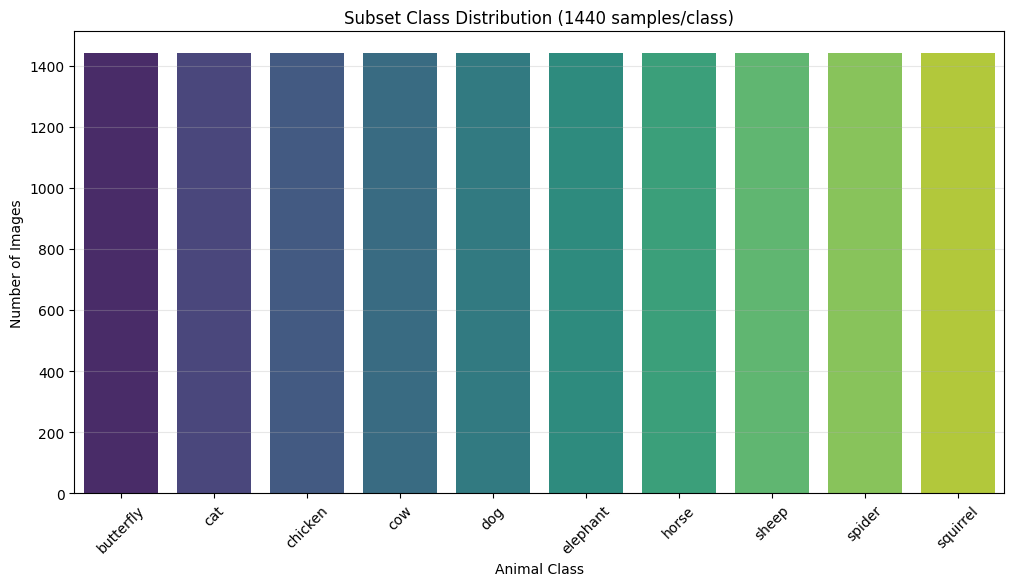


Random Samples from Created Subset:


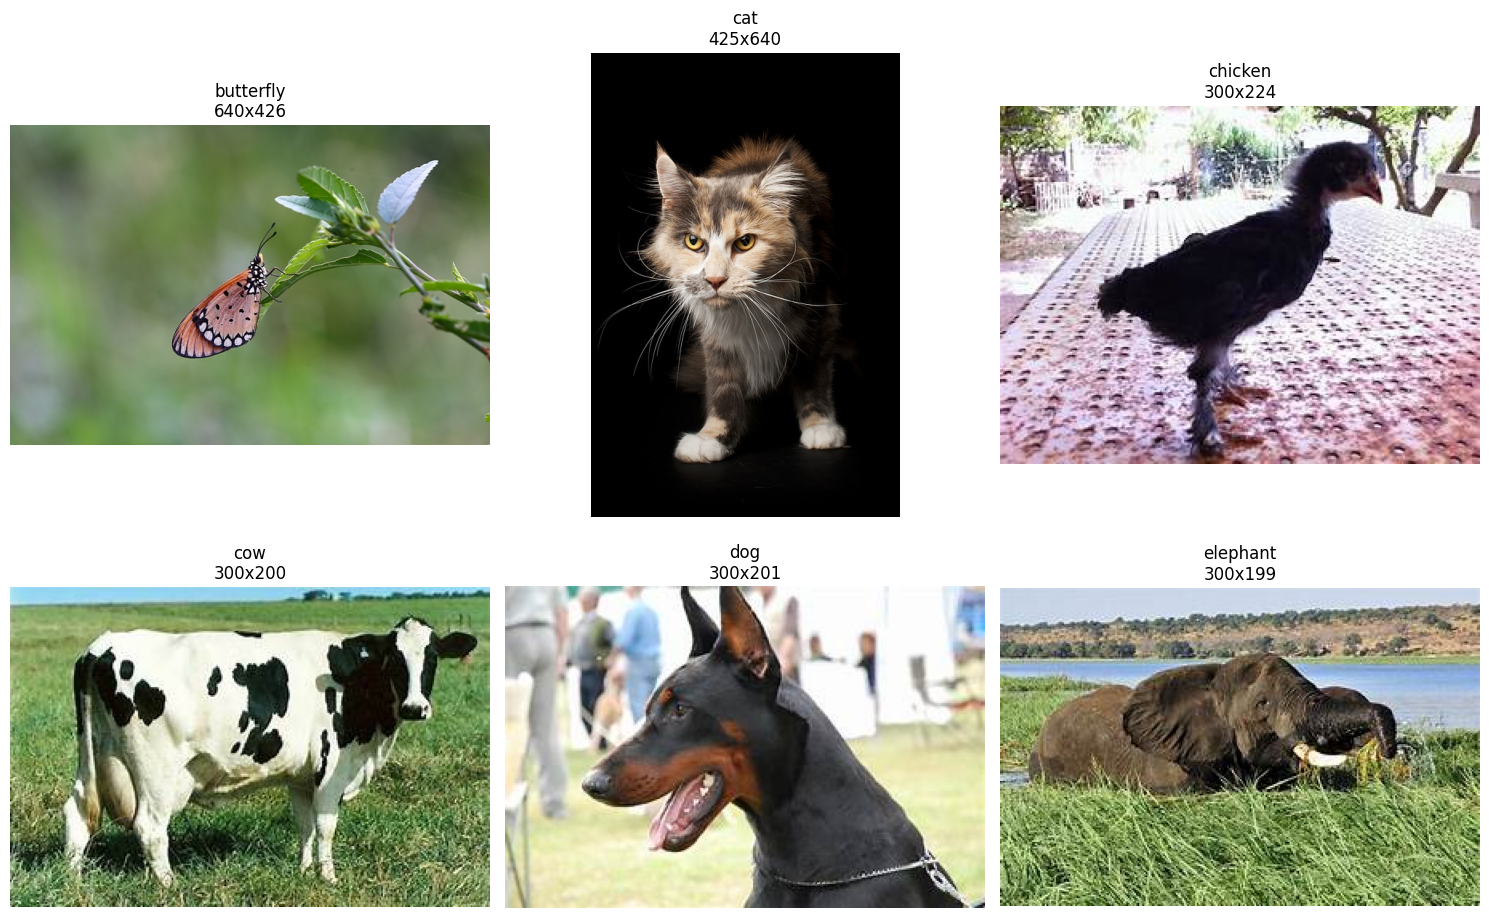


CREATING TUNING SUBSET (100 samples/class)

=== Tuning Subset ===
       Class  Count
0  butterfly    100
1        cat    100
2    chicken    100
3        cow    100
4        dog    100
5   elephant    100
6      horse    100
7      sheep    100
8     spider    100
9   squirrel    100

Total tuning samples: 1000

BLOCK 1.2 execution time: 2.84 seconds


In [26]:
# BLOCK 1.2: Subset Creation and Visualization

start_time = time.time()

print("\n" + "="*50)
print("CREATING BALANCED SUBSET")
print("="*50)

# Create balanced subset
subset_samples = {}
for class_name in class_names:
    class_dir = os.path.join(DATA_PATH, class_name)
    if os.path.isdir(class_dir):
        img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            # If not enough images are present, take all available
        if len(img_files) < SUBSET_SIZE_PER_CLASS:
            print(f"Warning: Class {class_name} has only {len(img_files)} images (requested {SUBSET_SIZE_PER_CLASS})")
            selected_files = img_files  # Take all if not enough
        else:
            selected_files = np.random.choice(img_files, size=SUBSET_SIZE_PER_CLASS, replace=False)
        subset_samples[class_name] = selected_files

# Create DataFrame for subset
subset_data = pd.DataFrame({
    'Class': list(subset_samples.keys()),
    'Count': [len(files) for files in subset_samples.values()]
})

print("\n=== Created Subset ===")
print(subset_data)
print(f"\nTotal subset samples: {subset_data['Count'].sum()}")

# Visualization 1: Subset Pie Chart
plt.figure(figsize=(10, 10))
plt.pie(subset_data['Count'], labels=subset_data['Class'],
        autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title(f'Subset Class Distribution ({SUBSET_SIZE_PER_CLASS} samples/class)\n(Pie Chart)', pad=20)
plt.axis('equal')
plt.show()

# Visualization 2: Subset Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=subset_data, palette='viridis')
plt.title(f'Subset Class Distribution ({SUBSET_SIZE_PER_CLASS} samples/class)')
plt.xticks(rotation=45)
plt.ylabel('Number of Images')
plt.xlabel('Animal Class')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Visualization 3: Random Samples from Subset
print("\nRandom Samples from Created Subset:")
plt.figure(figsize=(15, 10))
displayed_classes = 0
for i, class_name in enumerate(class_names):
    # Check if class exists in subset and has images
    if class_name in subset_samples and len(subset_samples[class_name]) > 0:
        img_file = np.random.choice(subset_samples[class_name])
        img_path = os.path.join(DATA_PATH, class_name, img_file)
        try:
            img = Image.open(img_path)

            plt.subplot(2, 3, displayed_classes+1)
            plt.imshow(img)
            plt.title(f"{class_name}\n{img.size[0]}x{img.size[1]}")
            plt.axis('off')

            displayed_classes += 1
            if displayed_classes >= 6:  # Show max 6 samples
                break
        except Exception as e:
            print(f"Could not load image {img_path}: {str(e)}")

plt.tight_layout()
plt.show()

# Create tuning subset
print("\n" + "="*50)
print(f"CREATING TUNING SUBSET ({TUNING_SUBSET_SIZE} samples/class)")
print("="*50)

tuning_samples = {}
for class_name in class_names:
    if class_name in subset_samples and len(subset_samples[class_name]) > 0:
        available_samples = subset_samples[class_name]
        tuning_size = min(TUNING_SUBSET_SIZE, len(available_samples))
        tuning_samples[class_name] = np.random.choice(available_samples, size=tuning_size, replace=False)

# Create DataFrame for tuning subset
tuning_data = pd.DataFrame({
    'Class': list(tuning_samples.keys()),
    'Count': [len(files) for files in tuning_samples.values()]
})

print("\n=== Tuning Subset ===")
print(tuning_data)
print(f"\nTotal tuning samples: {tuning_data['Count'].sum()}")

end_time = time.time()
print(f"\nBLOCK 1.2 execution time: {end_time - start_time:.2f} seconds")

In [27]:
# BLOCK 2: Dataset and DataLoader Classes
start_time = time.time()

class AnimalDataset(Dataset):
    def __init__(self, data_path, samples_dict, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.classes = sorted(samples_dict.keys())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = []

        for class_name, files in samples_dict.items():
            for file in files:
                self.samples.append((os.path.join(data_path, class_name, file), self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    # In your AnimalDataset class, images are loaded and transformed:
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')  # Convert to RGB

        if self.transform:
            img = self.transform(img) # Apply transforms

        return img, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # Resize
    transforms.RandomHorizontalFlip(),              # Augmentation
    transforms.RandomRotation(15),                  # Augmentation
    transforms.ToTensor(),                          # Convert to tensor
    transforms.Normalize(                           # Normalize
        mean=[0.485, 0.456, 0.406],                # ImageNet stats
        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),        # Resize
    transforms.ToTensor(),                          # Convert to tensor
    transforms.Normalize(                           # Normalize
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

# Create datasets
full_subset_dataset = AnimalDataset(DATA_PATH, subset_samples, train_transform)
tuning_dataset = AnimalDataset(DATA_PATH, tuning_samples, train_transform)

# Split into train/val (80/20)
def train_val_split(dataset, val_split=0.2):
    dataset_size = len(dataset)
    val_size = int(val_split * dataset_size)
    train_size = dataset_size - val_size
    return random_split(dataset, [train_size, val_size])

train_dataset, val_dataset = train_val_split(full_subset_dataset)
tuning_train, tuning_val = train_val_split(tuning_dataset)

print(f"\nFull subset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print(f"Tuning subset sizes - Train: {len(tuning_train)}, Val: {len(tuning_val)}")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
tuning_train_loader = DataLoader(tuning_train, batch_size=BATCH_SIZE, shuffle=True)
tuning_val_loader = DataLoader(tuning_val, batch_size=BATCH_SIZE, shuffle=False)

end_time = time.time()
print(f"\nBLOCK 2 execution time: {end_time - start_time:.2f} seconds")


Full subset sizes - Train: 11520, Val: 2880
Tuning subset sizes - Train: 800, Val: 200

BLOCK 2 execution time: 0.06 seconds



=== Transformed Image Tensor Info ===
Image Tensor Shape: torch.Size([3, 224, 224])
Label Sample: [6, 1, 5, 1, 3, 0]


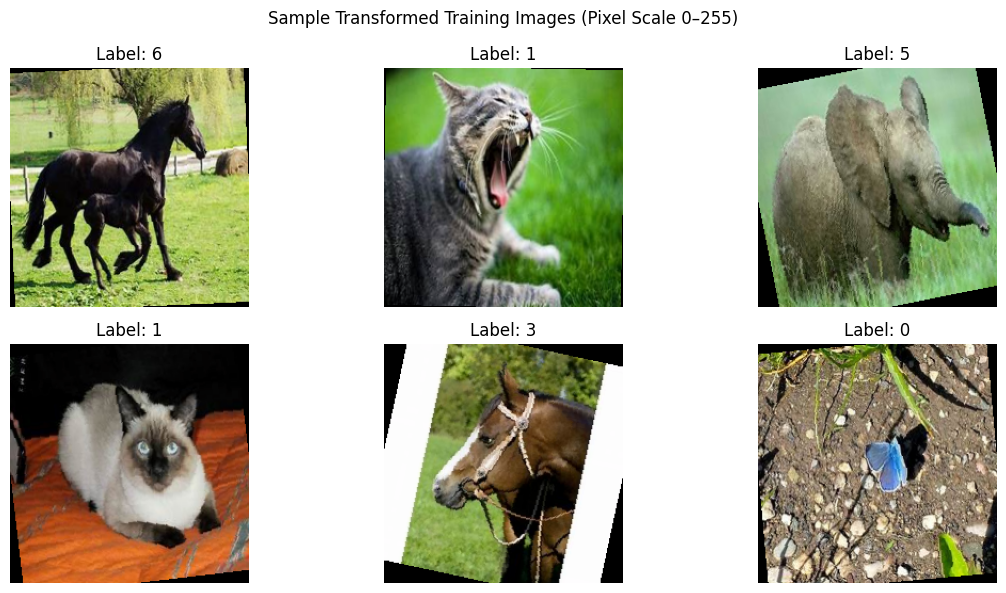

In [28]:
# BLOCK 2.1: Visualize Transformed Images

# Denormalize and convert to pixel scale [0–255]
def to_pixel_scale(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean                # De-normalize to [0–1]
    img = torch.clamp(img * 255, 0, 255)         # Scale to [0–255]
    return img.byte()                            # Convert to uint8

# Get a batch from train_loader
images, labels = next(iter(train_loader))

# Show info
print("\n=== Transformed Image Tensor Info ===")
print(f"Image Tensor Shape: {images[0].shape}")
print(f"Label Sample: {labels[:6].tolist()}")

# Plot first 6 images
plt.figure(figsize=(12, 6))
for i in range(6):
    img = to_pixel_scale(images[i]).permute(1, 2, 0).numpy()  # CHW to HWC
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.suptitle("Sample Transformed Training Images (Pixel Scale 0–255)")
plt.tight_layout()
plt.show()


In [29]:
# BLOCK 3: Model Wrapper Class and Initialization

start_time = time.time()

# Detect if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Custom wrapper class to adapt pre-trained CNN models for 10-class classification
class AnimalClassifier(nn.Module):
    def __init__(self, base_model, num_classes=NUM_CLASSES):
        super(AnimalClassifier, self).__init__()
        self.base_model = base_model

        # Extract the input features from the last layer of the base model
        if isinstance(self.base_model, models.DenseNet):
            in_features = self.base_model.classifier.in_features
            self.base_model.classifier = nn.Identity()  # Remove original DenseNet classifier
        elif isinstance(self.base_model, models.EfficientNet):
            in_features = self.base_model.classifier[1].in_features
            self.base_model.classifier = nn.Identity()  # Remove original EfficientNet classifier
        else:
            raise ValueError("Unsupported model architecture")

        # New fully connected layer to classify into 'num_classes' classes
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.base_model(x)  # Get features from base model
        return self.fc(features)       # Apply final classifier layer

# Function to load and wrap a pre-trained model
def initialize_model(model_name, num_classes=NUM_CLASSES):
    if model_name == 'densenet121':
        model = models.densenet121(pretrained=True)  # Load pre-trained DenseNet
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=True)  # Load pre-trained EfficientNet
    else:
        raise ValueError("Unknown model name")

    # Freeze all model parameters to use as a fixed feature extractor (fine-tuning later if needed)
    for param in model.parameters():
        param.requires_grad = False

    # Return wrapped model with custom classifier
    return AnimalClassifier(model, num_classes).to(device)

# Instantiate the models
print("\nInitializing models...")
densenet = initialize_model('densenet121')
efficientnet = initialize_model('efficientnet_b0')

# Helper to count only trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print number of trainable parameters (only the final layer should be trainable for now)
print(f"\nDenseNet121 trainable parameters: {count_parameters(densenet):,}")
print(f"EfficientNet-B0 trainable parameters: {count_parameters(efficientnet):,}")

# Test a forward pass with dummy input to check for correctness
print("\nTesting forward pass...")
test_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)  # Simulate a batch of 2 images
try:
    with torch.no_grad():
        densenet_out = densenet(test_input)
        efficientnet_out = efficientnet(test_input)
    print(f"DenseNet121 output shape: {densenet_out.shape}")  # Should be [2, 10]
    print(f"EfficientNet-B0 output shape: {efficientnet_out.shape}")
    print("Forward pass successful!")
except Exception as e:
    print(f"Forward pass failed: {str(e)}")

end_time = time.time()
print(f"\nBLOCK 3 execution time: {end_time - start_time:.2f} seconds")



Using device: cpu

Initializing models...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the 


DenseNet121 trainable parameters: 10,250
EfficientNet-B0 trainable parameters: 12,810

Testing forward pass...
DenseNet121 output shape: torch.Size([2, 10])
EfficientNet-B0 output shape: torch.Size([2, 10])
Forward pass successful!

BLOCK 3 execution time: 1.56 seconds


In [32]:
# BLOCK 4: Training and Evaluation Functions
start_time = time.time()

# Function to train the model for multiple epochs
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    train_losses, val_losses = [], []   # Store training and validation losses per epoch
    train_accs, val_accs = [] , []      # Store training and validation accuracy per epoch
    best_val_acc = 0.0                  # Track best validation accuracy for saving the best model

    for epoch in range(num_epochs):
        model.train()                  # Set model to training mode
        running_loss = 0.0             # Accumulate training loss
        correct = 0                    # Count correct predictions
        total = 0                      # Total number of samples seen

        for inputs, labels in train_loader:    # Iterate over training data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()             # Clear previous gradients
            outputs = model(inputs)           # Forward pass
            loss = criterion(outputs, labels) # Compute loss
            loss.backward()                   # Backpropagation
            optimizer.step()                  # Update weights

            running_loss += loss.item() * inputs.size(0)   # Accumulate loss
            _, predicted = torch.max(outputs.data, 1)       # Get predicted class
            total += labels.size(0)                         # Update total sample count
            correct += (predicted == labels).sum().item()   # Update correct prediction count

        epoch_loss = running_loss / total      # Average loss for this epoch
        epoch_acc = correct / total            # Accuracy for this epoch
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # Perform evaluation on validation set
        val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Save best model weights based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model.base_model.__class__.__name__}.pth')

        # Print metrics after each epoch
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')

    # Return a dictionary with full training history
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }

# Function to evaluate model (used in validation phase and after training)
def evaluate_model(model, data_loader, criterion):
    model.eval()                    # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []                 # Store predictions
    all_labels = []               # Store ground truth labels

    with torch.no_grad():         # Disable gradient computation
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')  # Weighted F1 score

    return epoch_loss, epoch_acc, epoch_f1

# Function to plot confusion matrix for the model's predictions
def plot_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)   # Generate confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

end_time = time.time()
print(f"\nBLOCK 4 execution time: {end_time - start_time:.2f} seconds")
# NO output until you call these functions later


# Function to plot training curves
def plot_training_curves(results, model_name='Model'):
    import matplotlib.pyplot as plt

    epochs = range(1, len(results['train_losses']) + 1)

    plt.figure(figsize=(12, 5))

    # --- Plot Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, results['train_losses'], label='Train Loss')
    plt.plot(epochs, results['val_losses'], label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # --- Plot Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, results['train_accs'], label='Train Accuracy')
    plt.plot(epochs, results['val_accs'], label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



BLOCK 4 execution time: 0.00 seconds


In [ ]:
# BLOCK 5: Hyperparameter Tuning (Enhanced Manual Grid Search)
# why manual ? GridSearchCV Fails for PyTorch
#GridSearchCV expects .fit() and .predict() methods like in Scikit-learn.
#PyTorch uses .forward() and custom training loops — it doesn't follow the Scikit-learn interface.
#You need GPU acceleration and dynamic training behavior → GridSearchCV can't provide that.

start_time = time.time()

#all configurations (18 in total) are tested one by one
# Define the hyperparameter search space
grid_space = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'optimizer': ['adam', 'sgd'],
    'batch_size': [16, 32, 64]
}

# Convert tuning dataset to NumPy-style tensors for fast looping (since tuning sets are small)
def dataset_to_list(dataset):
    X, y = [], []
    for i in range(len(dataset)):
        img, label = dataset[i]
        X.append(img.numpy())
        y.append(label)
    return np.array(X), np.array(y)

# Prepare training and validation arrays from tuning sets
X_train, y_train = dataset_to_list(tuning_train)
X_val, y_val = dataset_to_list(tuning_val)

# Track best params, scores, models and all results
best_params = {}
best_score = {}
best_models = {}
all_results = {}

# Loop over both architectures
for model_name in ['densenet121', 'efficientnet_b0']:
    print(f"\n Grid Search for {model_name.upper()}")

    best_acc = 0.0
    config_results = []

    # Iterate over all hyperparameter combinations
    for config in ParameterGrid(grid_space):
        config_start = time.time()
        print(f"\n  Testing config: {config}")

        # Initialize a fresh model for this config
        model = initialize_model(model_name)
        criterion = nn.CrossEntropyLoss()

        # Select optimizer according to config
        if config['optimizer'] == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
        else:
            optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.9)

        # Quick training loop for 5 epochs on the small tuning set
        model.train()
        for epoch in range(5):  # Keep this small to reduce time
            for i in range(0, len(X_train), config['batch_size']):
                batch_X = torch.FloatTensor(X_train[i:i + config['batch_size']]).to(device)
                batch_y = torch.LongTensor(y_train[i:i + config['batch_size']]).to(device)

                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Evaluate performance on tuning validation set
        model.eval()
        correct = 0
        with torch.no_grad():
            for i in range(0, len(X_val), config['batch_size']):
                batch_X = torch.FloatTensor(X_val[i:i + config['batch_size']]).to(device)
                batch_y = torch.LongTensor(y_val[i:i + config['batch_size']]).to(device)
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == batch_y).sum().item()

        val_acc = correct / len(X_val)
        total_time = time.time() - config_start

        print(f" Accuracy: {val_acc:.4f} | Time: {total_time:.2f}s")

        # Save result for this config
        config_results.append({
            'config': config,
            'accuracy': val_acc,
            'time': total_time
        })

        # Save best config if this one is better
        if val_acc > best_acc:
            best_acc = val_acc
            best_params[model_name] = config.copy()
            best_score[model_name] = val_acc
            best_models[model_name] = model.state_dict().copy()
            print(" New Best Configuration Found!")

    # Save best model weights
    all_results[model_name] = config_results
    torch.save(best_models[model_name], f'best_{model_name}_gridsearch.pth')

# Summary of best results
print("\n FINAL BEST RESULTS")
for model_name in best_params:
    print(f"\n{model_name.upper()}")
    print(f" Best Accuracy: {best_score[model_name]:.4f}")
    print(f" Best Params  : {best_params[model_name]}")

# Print all tested configs sorted by accuracy
for model_name in all_results:
    print(f"\n All Results for {model_name.upper()}:")
    print("{:<15} {:<10} {:<12} {:<10} {:<10}".format("Learning Rate", "Optimizer", "Batch Size", "Accuracy", "Time(s)"))
    for result in sorted(all_results[model_name], key=lambda x: -x['accuracy']):
        cfg = result['config']
        print("{:<15.5f} {:<10} {:<12} {:<10.4f} {:<10.2f}".format(
            cfg['learning_rate'],
            cfg['optimizer'],
            cfg['batch_size'],
            result['accuracy'],
            result['time']
        ))

end_time = time.time()
print(f"\n Total Grid Search Time: {end_time - start_time:.2f} seconds")



 Grid Search for DENSENET121

  Testing config: {'batch_size': 16, 'learning_rate': 0.01, 'optimizer': 'adam'}
 Accuracy: 0.7950 | Time: 813.54s
 New Best Configuration Found!

  Testing config: {'batch_size': 16, 'learning_rate': 0.01, 'optimizer': 'sgd'}
 Accuracy: 0.8750 | Time: 812.85s
 New Best Configuration Found!

  Testing config: {'batch_size': 16, 'learning_rate': 0.001, 'optimizer': 'adam'}
 Accuracy: 0.8950 | Time: 813.07s
 New Best Configuration Found!

  Testing config: {'batch_size': 16, 'learning_rate': 0.001, 'optimizer': 'sgd'}
 Accuracy: 0.9000 | Time: 815.36s
 New Best Configuration Found!

  Testing config: {'batch_size': 16, 'learning_rate': 0.0001, 'optimizer': 'adam'}
 Accuracy: 0.7800 | Time: 814.24s

  Testing config: {'batch_size': 16, 'learning_rate': 0.0001, 'optimizer': 'sgd'}
 Accuracy: 0.8050 | Time: 813.06s

  Testing config: {'batch_size': 32, 'learning_rate': 0.01, 'optimizer': 'adam'}
 Accuracy: 0.8550 | Time: 1026.81s

  Testing config: {'batch_siz

In [ ]:
# BLOCK 6: Final Training on Full Subset (With Epoch Timings)
start_time = time.time()
print("=== BLOCK 6: Starting Final Training on Full Subset ===")

# ----------------------------------------
# STEP 1: Print best hyperparameters
print("\n=== Best Parameters from Grid Search ===")
for model_name in best_params:
    print(f"{model_name}: {best_params[model_name]}")
params_print_time = time.time()
print(f"→ Printed best parameters. Time: {params_print_time - start_time:.2f} seconds\n")

# ----------------------------------------
# STEP 2: Reinitialize models
densenet = initialize_model('densenet121')
efficientnet = initialize_model('efficientnet_b0')
print("→ Models reinitialized.")
model_init_time = time.time()
print(f"→ Model initialization time: {model_init_time - params_print_time:.2f} seconds\n")

# ----------------------------------------
# STEP 3: Set up DataLoaders with best batch sizes
densenet_train_loader = DataLoader(train_dataset, batch_size=best_params['densenet121']['batch_size'], shuffle=True)
densenet_val_loader = DataLoader(val_dataset, batch_size=best_params['densenet121']['batch_size'], shuffle=False)

efficientnet_train_loader = DataLoader(train_dataset, batch_size=best_params['efficientnet_b0']['batch_size'], shuffle=True)
efficientnet_val_loader = DataLoader(val_dataset, batch_size=best_params['efficientnet_b0']['batch_size'], shuffle=False)
print("→ DataLoaders set up using best batch sizes.")
loader_time = time.time()
print(f"→ DataLoader setup time: {loader_time - model_init_time:.2f} seconds\n")

# ----------------------------------------
# STEP 4: Setup optimizers
densenet_optimizer = (
    optim.Adam(densenet.parameters(), lr=best_params['densenet121']['learning_rate'])
    if best_params['densenet121']['optimizer'] == 'adam'
    else optim.SGD(densenet.parameters(), lr=best_params['densenet121']['learning_rate'], momentum=0.9)
)
efficientnet_optimizer = (
    optim.Adam(efficientnet.parameters(), lr=best_params['efficientnet_b0']['learning_rate'])
    if best_params['efficientnet_b0']['optimizer'] == 'adam'
    else optim.SGD(efficientnet.parameters(), lr=best_params['efficientnet_b0']['learning_rate'], momentum=0.9)
)
print("→ Optimizers created based on best hyperparameters.")
opt_time = time.time()
print(f"→ Optimizer setup time: {opt_time - loader_time:.2f} seconds\n")

# ----------------------------------------
# STEP 5: Train DenseNet121
print("\n=== Training DenseNet121 with Best Params ===")
dn_train_start = time.time()
densenet_results = train_model(
    densenet,
    densenet_train_loader,
    densenet_val_loader,
    densenet_optimizer,
    criterion,
    num_epochs=10
)
dn_train_end = time.time()
print(f"→ DenseNet121 training complete. Time: {(dn_train_end - dn_train_start):.1f}s")
print(f"→ Best Val Accuracy: {densenet_results['best_val_acc']:.4f}\n")

# ----------------------------------------
# STEP 6: Train EfficientNet-B0
print("\n=== Training EfficientNet-B0 with Best Params ===")
en_train_start = time.time()
efficientnet_results = train_model(
    efficientnet,
    efficientnet_train_loader,
    efficientnet_val_loader,
    efficientnet_optimizer,
    criterion,
    num_epochs=10
)
en_train_end = time.time()
print(f"→ EfficientNet-B0 training complete. Time: {(en_train_end - en_train_start):.1f}s")
print(f"→ Best Val Accuracy: {efficientnet_results['best_val_acc']:.4f}\n")

# ----------------------------------------
# STEP 7: Plot training/validation loss and accuracy curves
print("=== Plotting training curves ===")
plot_training_curves(densenet_results, 'DenseNet121')
print("→ DenseNet121 curves plotted.")
plot_training_curves(efficientnet_results, 'EfficientNet-B0')
print("→ EfficientNet-B0 curves plotted.\n")
plot_time = time.time()
print(f"→ Total plotting time: {plot_time - en_train_end:.2f} seconds\n")

# ----------------------------------------
# STEP 8: Save trained model weights
torch.save(densenet.state_dict(), 'final_densenet.pth')
torch.save(efficientnet.state_dict(), 'final_efficientnet.pth')
save_time = time.time()
print("→ Final model weights saved.")
print(f"→ Saving time: {save_time - plot_time:.2f} seconds\n")

# ----------------------------------------
# Final total runtime
end_time = time.time()
print(f"\n BLOCK 6 COMPLETE. Total time: {(end_time - start_time) / 60:.2f} minutes")


=== BLOCK 6: Starting Final Training on Full Subset ===

=== Best Parameters from Grid Search ===
densenet121: {'batch_size': 64, 'learning_rate': 0.01, 'optimizer': 'sgd'}
efficientnet_b0: {'batch_size': 32, 'learning_rate': 0.01, 'optimizer': 'sgd'}
→ Printed best parameters. Time: 0.01 seconds

→ Models reinitialized.
→ Model initialization time: 1.37 seconds

→ DataLoaders set up using best batch sizes.
→ DataLoader setup time: 0.00 seconds

→ Optimizers created based on best hyperparameters.
→ Optimizer setup time: 0.00 seconds


=== Training DenseNet121 with Best Params ===
Epoch 1/10 | Time: 7242.8s | Train Loss: 0.3528, Acc: 0.8923 | Val Loss: 0.1783, Acc: 0.9455, F1: 0.9455
Epoch 2/10 | Time: 4405.2s | Train Loss: 0.1803, Acc: 0.9451 | Val Loss: 0.1562, Acc: 0.9524, F1: 0.9526
Epoch 3/10 | Time: 4406.6s | Train Loss: 0.1616, Acc: 0.9500 | Val Loss: 0.1504, Acc: 0.9583, F1: 0.9584
Epoch 4/10 | Time: 4425.9s | Train Loss: 0.1484, Acc: 0.9552 | Val Loss: 0.1576, Acc: 0.9556, F1: 

=== BLOCK 6.1: EfficientNet-B0 Final Training (With Regularization) ===


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== Training EfficientNet-B0 ===
Epoch 1/10: Train Loss: 0.5238, Train Acc: 0.8602 | Val Loss: 0.2469, Val Acc: 0.9316, Val F1: 0.9317
Epoch 2/10: Train Loss: 0.2943, Train Acc: 0.9135 | Val Loss: 0.2222, Val Acc: 0.9340, Val F1: 0.9341
Epoch 3/10: Train Loss: 0.2601, Train Acc: 0.9183 | Val Loss: 0.1965, Val Acc: 0.9451, Val F1: 0.9453
Epoch 4/10: Train Loss: 0.2507, Train Acc: 0.9244 | Val Loss: 0.1907, Val Acc: 0.9413, Val F1: 0.9414
Epoch 5/10: Train Loss: 0.2344, Train Acc: 0.9261 | Val Loss: 0.1909, Val Acc: 0.9465, Val F1: 0.9466
Epoch 6/10: Train Loss: 0.2208, Train Acc: 0.9311 | Val Loss: 0.1919, Val Acc: 0.9420, Val F1: 0.9421
Epoch 7/10: Train Loss: 0.2218, Train Acc: 0.9285 | Val Loss: 0.1908, Val Acc: 0.9361, Val F1: 0.9363
Epoch 8/10: Train Loss: 0.2150, Train Acc: 0.9314 | Val Loss: 0.1797, Val Acc: 0.9462, Val F1: 0.9463
Epoch 9/10: Train Loss: 0.2088, Train Acc: 0.9324 | Val Loss: 0.1744, Val Acc: 0.9500, Val F1: 0.9500
Epoch 10/10: Train Loss: 0.2019, Train Acc: 0.93

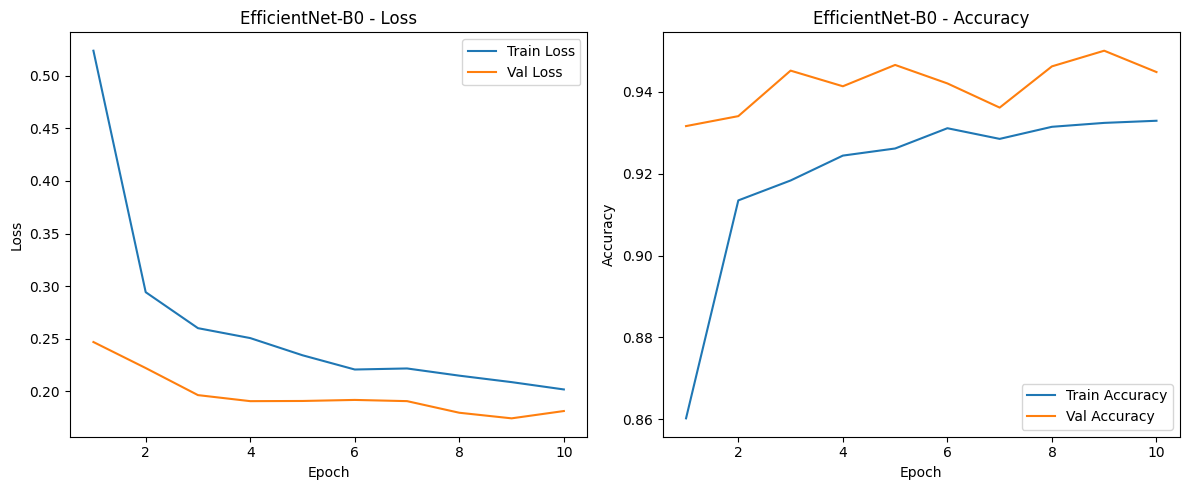


BLOCK 6.1 Completed in 275.34 minutes
Best Validation Accuracy: 0.9500


In [33]:
# BLOCK 6.1: Final Training of EfficientNet-B0 with Regularization
start_time = time.time()
print("=== BLOCK 6.1: EfficientNet-B0 Final Training (With Regularization) ===")

# Load best hyperparameters from Block 5 results
best_params_efficientnet = {
    'batch_size': 32,
    'learning_rate': 0.01,
    'optimizer': 'sgd',
    'weight_decay': 1e-4   # L2 Regularization
}

# Recreate DataLoaders using best batch size
efficientnet_train_loader = DataLoader(train_dataset, batch_size=best_params_efficientnet['batch_size'], shuffle=True)
efficientnet_val_loader = DataLoader(val_dataset, batch_size=best_params_efficientnet['batch_size'], shuffle=False)

# Re-initialize EfficientNet-B0
efficientnet = initialize_model('efficientnet_b0')

# Define loss function
criterion = nn.CrossEntropyLoss()

# Set up optimizer with regularization (L2 = weight_decay)
efficientnet_optimizer = optim.SGD(
    efficientnet.parameters(),
    lr=best_params_efficientnet['learning_rate'],
    momentum=0.9,
    weight_decay=best_params_efficientnet['weight_decay']
)

# Train EfficientNet-B0
print("\n=== Training EfficientNet-B0 ===")
efficientnet_results = train_model(
    efficientnet,
    efficientnet_train_loader,
    efficientnet_val_loader,
    efficientnet_optimizer,
    criterion,
    num_epochs=10
)

# Plot training curves
plot_training_curves(efficientnet_results, 'EfficientNet-B0')

# Save the final model
torch.save(efficientnet.state_dict(), 'final_efficientnet_reg.pth')

end_time = time.time()
print(f"\nBLOCK 6.1 Completed in {(end_time - start_time)/60:.2f} minutes")
print(f"Best Validation Accuracy: {efficientnet_results['best_val_acc']:.4f}")


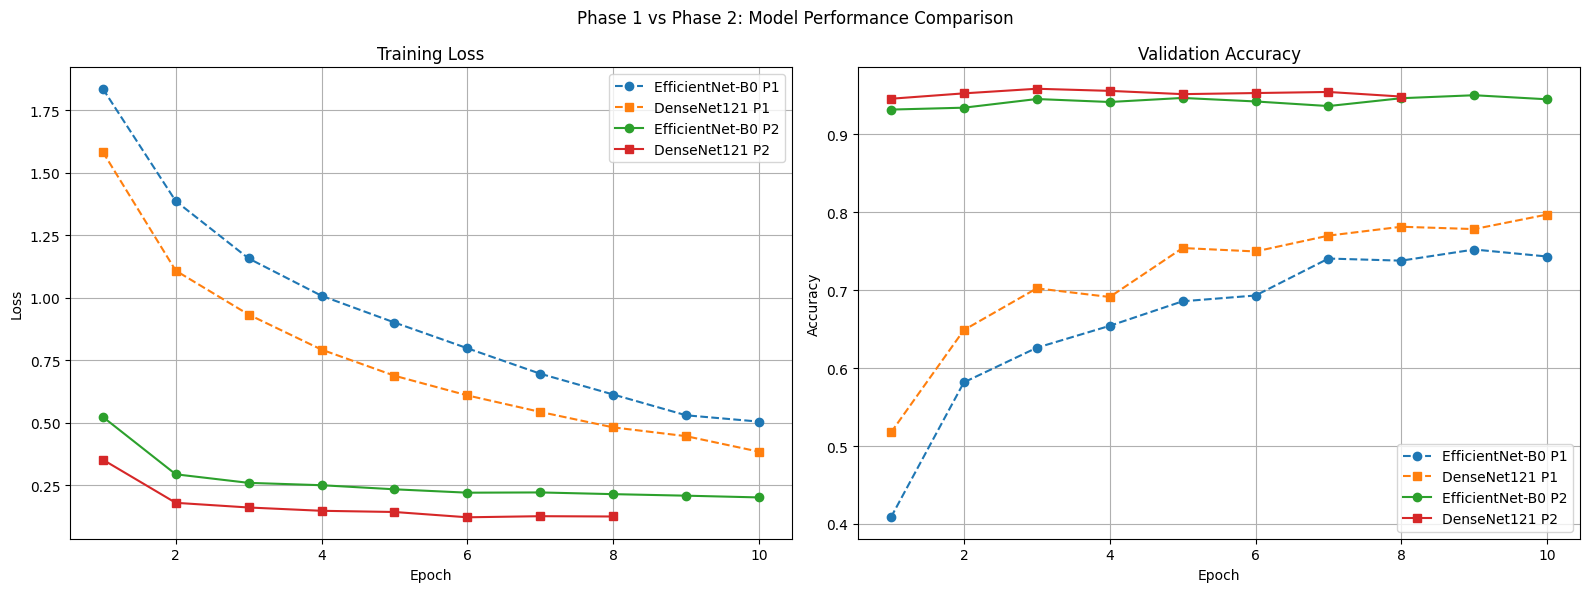

In [54]:
# Extract updated EfficientNet-B0 Phase 2 results from Block 6.1
effnet_p2_loss = efficientnet_results['train_losses']
effnet_p2_val_acc = efficientnet_results['val_accs']
epochs_p2 = list(range(1, len(effnet_p2_loss) + 1))

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Phase 1 vs Phase 2: Model Performance Comparison")

# Training Loss
axs[0].plot(epochs, effnet_p1_loss, label="EfficientNet-B0 P1", linestyle='--', marker='o')
axs[0].plot(epochs, densenet_p1_loss, label="DenseNet121 P1", linestyle='--', marker='s')
axs[0].plot(epochs_p2, effnet_p2_loss, label="EfficientNet-B0 P2", marker='o')
axs[0].plot(range(1, len(densenet_p2_loss)+1), densenet_p2_loss, label="DenseNet121 P2", marker='s')
axs[0].set_title("Training Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Validation Accuracy
axs[1].plot(epochs, effnet_p1_val_acc, label="EfficientNet-B0 P1", linestyle='--', marker='o')
axs[1].plot(epochs, densenet_p1_val_acc, label="DenseNet121 P1", linestyle='--', marker='s')
axs[1].plot(epochs_p2, effnet_p2_val_acc, label="EfficientNet-B0 P2", marker='o')
axs[1].plot(range(1, len(densenet_p2_val_acc)+1), densenet_p2_val_acc, label="DenseNet121 P2", marker='s')
axs[1].set_title("Validation Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


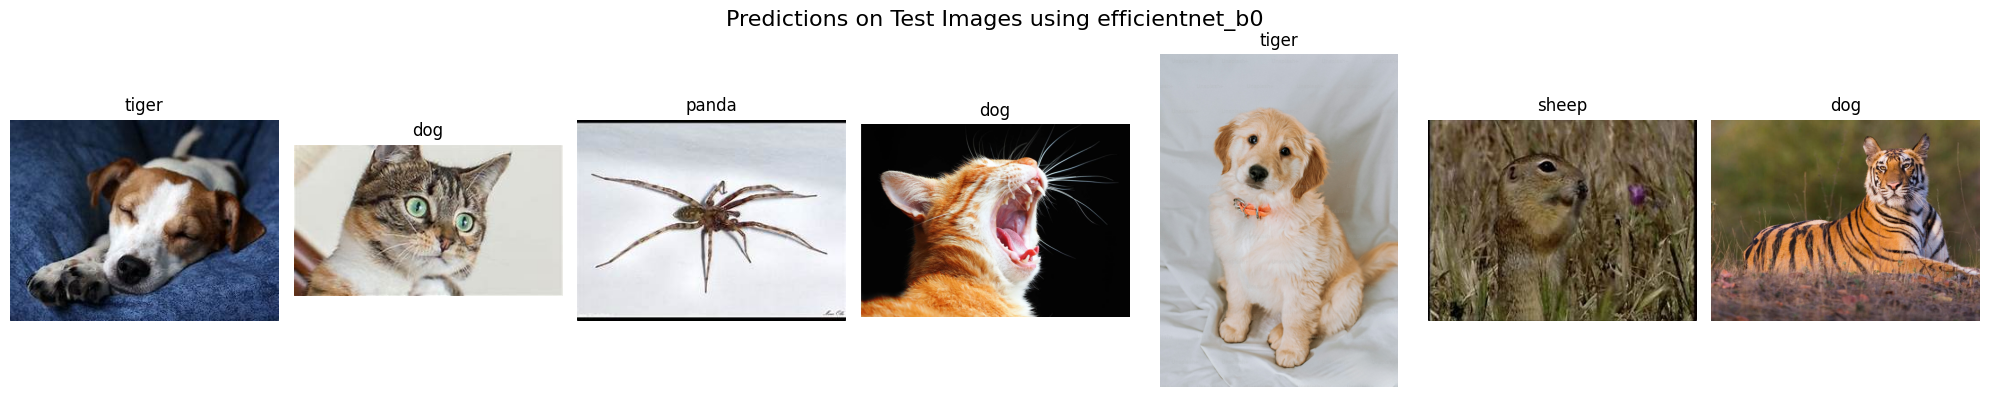

In [55]:
# BLOCK 9: Multi-Image Testing & Visualization

# Define paths to test images
test_image_paths = [
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/1.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/2.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/3.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/4.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/5.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/7.jpg",
    "/content/drive/MyDrive/CAD/LasalleStudy/4-CNN/cnn_project/testIMG/6.jpg"
]

#  Ensure same image size and device
IMG_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = initialize_model('efficientnet_b0')
model.load_state_dict(torch.load('final_efficientnet_reg.pth', map_location=device))
model.to(device)
model.eval()

#Class names (same order as used in training)
class_names = ['cat', 'dog', 'elephant', 'lion', 'tiger', 'zebra', 'monkey', 'cow', 'panda', 'sheep']

#  Define transform
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#  Create figure
plt.figure(figsize=(20, 4))  # 5 images in a row

# Loop through images
for idx, img_path in enumerate(test_image_paths):
    img = Image.open(img_path).convert('RGB')
    input_tensor = test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted_class = torch.max(output, 1)
        predicted_label = class_names[predicted_class.item()]

    # Display image
    plt.subplot(1, 7, idx+1)
    plt.imshow(img)
    plt.title(predicted_label)
    plt.axis('off')

plt.suptitle("Predictions on Test Images using efficientnet_b0", fontsize=16)
plt.tight_layout()
plt.show()
